<a href="https://colab.research.google.com/github/Shivam250124/Machine_Learning-/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df=pd.read_csv("car_ownership.csv")
df.head()

,monthly_salary,owns_car
0,22000,0
1,25000,0
2,47000,1
3,52000,0
4,46000,1


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
x=df[['monthly_salary']]
y=df[['owns_car']]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8888888888888888

In [5]:
x_test

,monthly_salary
8,62000
13,29000
9,61000
21,26000
0,22000
11,28000
16,25000
17,58000
12,27000


In [8]:
y_test

,owns_car
8,1
13,0
9,1
21,0
0,0
11,0
16,1
17,1
12,0


In [24]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 1, 0, 0, 0, 0, 1, 0])

In [11]:
8/9
#acurracy=right prediction /total prediction

0.8888888888888888

In [12]:
model.predict_proba(x_test)

array([[0.04530932, 0.95469068],
       [0.80955349, 0.19044651],
       [0.05158003, 0.94841997],
       [0.86480041, 0.13519959],
       [0.91687254, 0.08312746],
       [0.82967465, 0.17032535],
       [0.87995016, 0.12004984],
       [0.07564619, 0.92435381],
       [0.84806892, 0.15193108]])

In [13]:
model.coef_,model.intercept_

(array([[0.00013621]]), array([-5.39725076]))

In [14]:
import math
def sigmoid(x):
  return 1/(1+math.exp(-x))

In [19]:
def prediction_function(salary,model):
  z=model.coef_*salary+model.intercept_
  y=sigmoid(z)
  return y

In [20]:
z=model.coef_*62000+model.intercept_
z[0][0]

np.float64(3.047874614448304)

In [22]:
prediction_function(29000,model)

/tmp/ipykernel_704/3748165616.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1/(1+math.exp(-x))


0.1904465115158154

In [25]:
from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4

    accuracy                           0.89         9
   macro avg       0.92      0.88      0.88         9
weighted avg       0.91      0.89      0.89         9



In [29]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[5, 0],
       [1, 3]])

In [30]:
cm=confusion_matrix(y_test,y_pred)

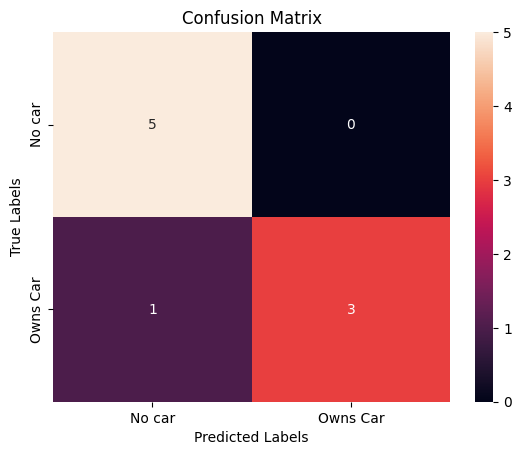

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt # Import matplotlib.pyplot for plt.xlabel, plt.ylabel, plt.title, plt.show
classes = ["No car","Owns Car"]
sns.heatmap(cm ,annot=True, xticklabels=classes,yticklabels=classes) # Corrected 'xtickalabels' to 'xticklabels'
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()